In [2]:
import pandas as pd
import numpy as np

In [3]:
# 1. Load Datasets using relative paths
orders = pd.read_csv('olist_orders_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [4]:
# 2. Convert Date columns to Datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [28]:
# 3. Handle Missing/Non-Delivered orders (Filter to delivered orders only)
delivered_orders = orders[orders['order_status'] == 'delivered'].dropna(subset=['order_delivered_customer_date']).copy()

In [7]:
# 4. Calculate Delay (Story 2)
# Negative value = late (delivered after estimated date)
# Positive value = on time (delivered before estimated date)
delivered_orders['delay_days'] = (delivered_orders['order_estimated_delivery_date'] - delivered_orders['order_delivered_customer_date']).dt.total_seconds() / 86400

In [8]:

def classify_delivery(days_diff):
    if days_diff >= 0:
        return 'On Time'
    elif days_diff > -5:
        return 'Late'
    else:
        return 'Super Late'

In [9]:
delivered_orders['delivery_status'] = delivered_orders['delay_days'].apply(classify_delivery)

In [11]:
# 5. Deduplicate Reviews (to avoid row duplication during 1-to-many join)
reviews_clean = reviews.sort_values('review_creation_date').drop_duplicates(subset=['order_id'], keep='last')

In [12]:
# 6. Master Join (Story 1)
master_df = delivered_orders.merge(reviews_clean[['order_id', 'review_score']], on='order_id', how='inner')
master_df = master_df.merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='inner')

In [13]:
print(f"Master Dataset Shape: {master_df.shape}")
print(master_df['delivery_status'].value_counts())

Master Dataset Shape: (95824, 13)
delivery_status
On Time       88163
Super Late     4093
Late           3568
Name: count, dtype: int64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Set clean aesthetic for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [16]:
# STORY 3: GEOGRAPHIC ANALYSIS (% Late per State)

state_summary = master_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x != 'On Time').sum())
).reset_index()

In [17]:
state_summary['pct_late'] = (state_summary['late_orders'] / state_summary['total_orders']) * 100
state_summary = state_summary.sort_values(by='pct_late', ascending=False)

print("--- TOP 5 STATES WITH HIGHEST % LATE DELIVERIES ---")
print(state_summary.head())

--- TOP 5 STATES WITH HIGHEST % LATE DELIVERIES ---
   customer_state  total_orders  late_orders   pct_late
1              AL           394           92  23.350254
9              MA           712          137  19.241573
16             PI           471           75  15.923567
5              CE          1273          194  15.239592
24             SE           334           50  14.970060


/tmp/ipykernel_912/3748425601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_summary, x='customer_state', y='pct_late', palette='Reds_r')


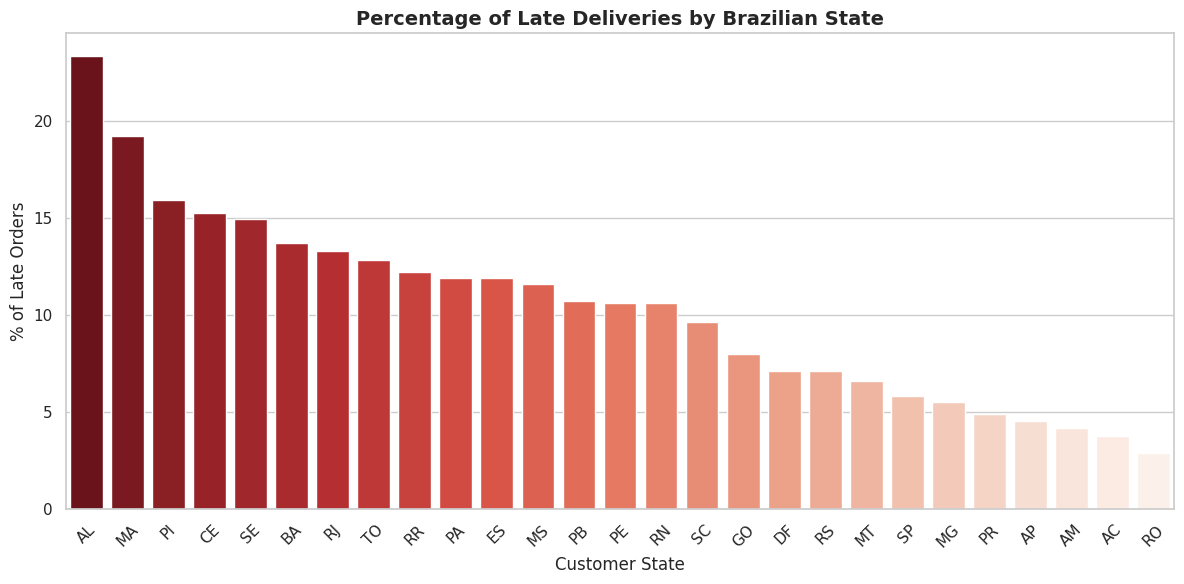

In [18]:
# Plot Story 3: Late Deliveries by State
plt.figure(figsize=(12, 6))
sns.barplot(data=state_summary, x='customer_state', y='pct_late', palette='Reds_r')
plt.title('Percentage of Late Deliveries by Brazilian State', fontsize=14, fontweight='bold')
plt.xlabel('Customer State')
plt.ylabel('% of Late Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# STORY 4: SENTIMENT CORRELATION (Review Score vs. Delay)
status_reviews = master_df.groupby('delivery_status')['review_score'].mean().reset_index()
print("\n--- AVERAGE REVIEW SCORE BY DELIVERY STATUS ---")
print(status_reviews)


--- AVERAGE REVIEW SCORE BY DELIVERY STATUS ---
  delivery_status  review_score
0            Late      3.460482
1         On Time      4.294001
2      Super Late      1.784999


/tmp/ipykernel_912/2915884349.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_reviews, x='delivery_status', y='review_score', order=['On Time', 'Late', 'Super Late'], palette=['#2ecc71', '#f39c12', '#e74c3c'])


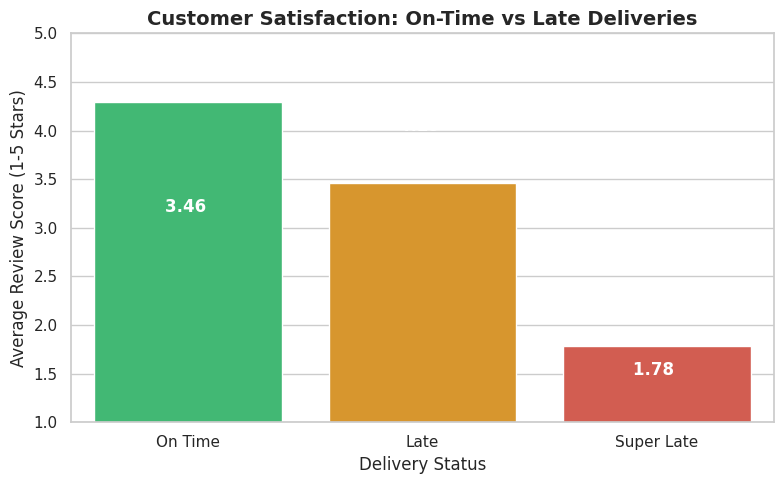

In [21]:
# Plot Story 4: Bar Chart Comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=status_reviews, x='delivery_status', y='review_score', order=['On Time', 'Late', 'Super Late'], palette=['#2ecc71', '#f39c12', '#e74c3c'])
plt.title('Customer Satisfaction: On-Time vs Late Deliveries', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score (1-5 Stars)')
plt.ylim(1, 5)
for index, row in status_reviews.iterrows():
    plt.text(index, row['review_score'] - 0.3, f"{row['review_score']:.2f} ", color='white', ha="center", fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:

# CANDIDATE'S CHOICE: Order Purchase Day vs. Delivery Delay
# Business Value: Identifying if orders placed on weekends face warehouse processing bottlenecks

master_df['purchase_day'] = master_df['order_purchase_timestamp'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekend_audit = master_df.groupby('purchase_day').agg(
    avg_score=('review_score', 'mean'),
    pct_late=('delivery_status', lambda x: (x != 'On Time').mean() * 100)
).reindex(day_order).reset_index()

print("\n--- CANDIDATE'S CHOICE: WEEKDAY VS WEEKEND AUDIT ---")
print(weekend_audit)


--- CANDIDATE'S CHOICE: WEEKDAY VS WEEKEND AUDIT ---
  purchase_day  avg_score  pct_late
0       Monday   4.172874  8.855638
1      Tuesday   4.165531  8.403089
2    Wednesday   4.181466  7.683571
3     Thursday   4.154959  7.452936
4       Friday   4.105368  8.330882
5     Saturday   4.140155  7.451992
6       Sunday   4.161092  7.458301


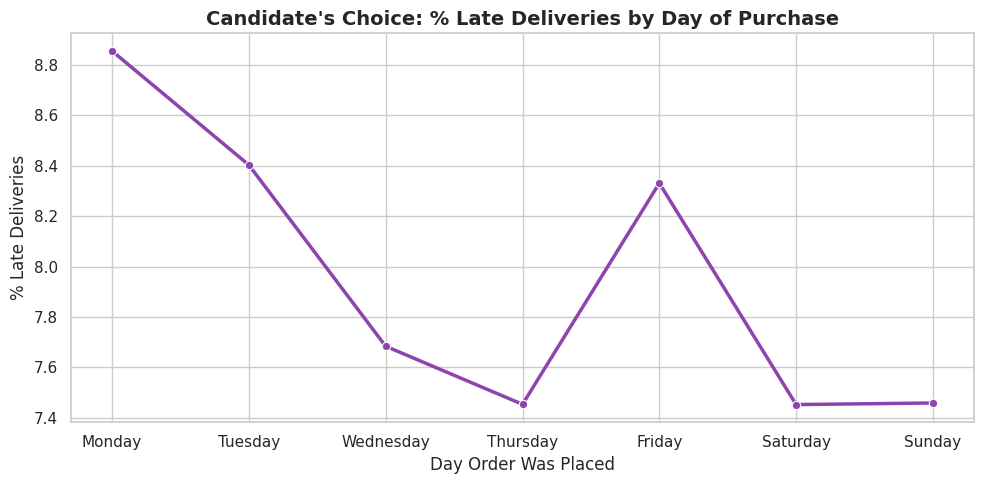

In [23]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=weekend_audit, x='purchase_day', y='pct_late', marker='o', color='#8e44ad', linewidth=2.5)
plt.title("Candidate's Choice: % Late Deliveries by Day of Purchase", fontsize=14, fontweight='bold')
plt.xlabel('Day Order Was Placed')
plt.ylabel('% Late Deliveries')
plt.tight_layout()
plt.show()

In [24]:
# Save clean summaries as light CSVs for your dashboard
state_summary.to_csv('state_delivery_audit.csv', index=False)
status_reviews.to_csv('sentiment_delivery_audit.csv', index=False)
weekend_audit.to_csv('weekday_bottleneck_audit.csv', index=False)
print("Files exported successfully!")

Files exported successfully!


In [25]:

# BONUS USER STORY: The "Translation" Challenge

# 1. Load Items, Products, and Category Translation files
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translations = pd.read_csv('product_category_name_translation.csv')

# 2. Map Portuguese product category names to English
products_translated = products.merge(translations, on='product_category_name', how='left')
# Fill unmapped/missing categories with 'other'
products_translated['product_category_name_english'] = products_translated['product_category_name_english'].fillna('other')

# 3. Merge with Order Items and Master Dataset (One category per order to prevent duplication)
items_with_category = order_items.merge(
    products_translated[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
).drop_duplicates(subset=['order_id'])

bonus_df = master_df.merge(items_with_category[['order_id', 'product_category_name_english']], on='order_id', how='left')

--- TOP 10 PRODUCT CATEGORIES WITH HIGHEST % LATE DELIVERIES ---
      product_category_name_english  total_orders  late_orders  \
26                      electronics          2488          245   
6                              baby          2741          251   
57                 office_furniture          1236          112   
17  construction_tools_construction           723           65   
56              musical_instruments           601           54   
43                    health_beauty          8562          757   
58                            other          1369          120   
7                    bed_bath_table          9072          788   
5                              auto          3774          323   
69                        telephony          4052          344   

    avg_review_score  pct_late  
26          4.128617  9.847267  
6           4.121489  9.157242  
57          3.650485  9.061489  
17          4.132780  8.990318  
56          4.247920  8.985025  
43        

/tmp/ipykernel_912/3291392778.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=significant_categories.head(10), x='pct_late', y='product_category_name_english', palette='magma')


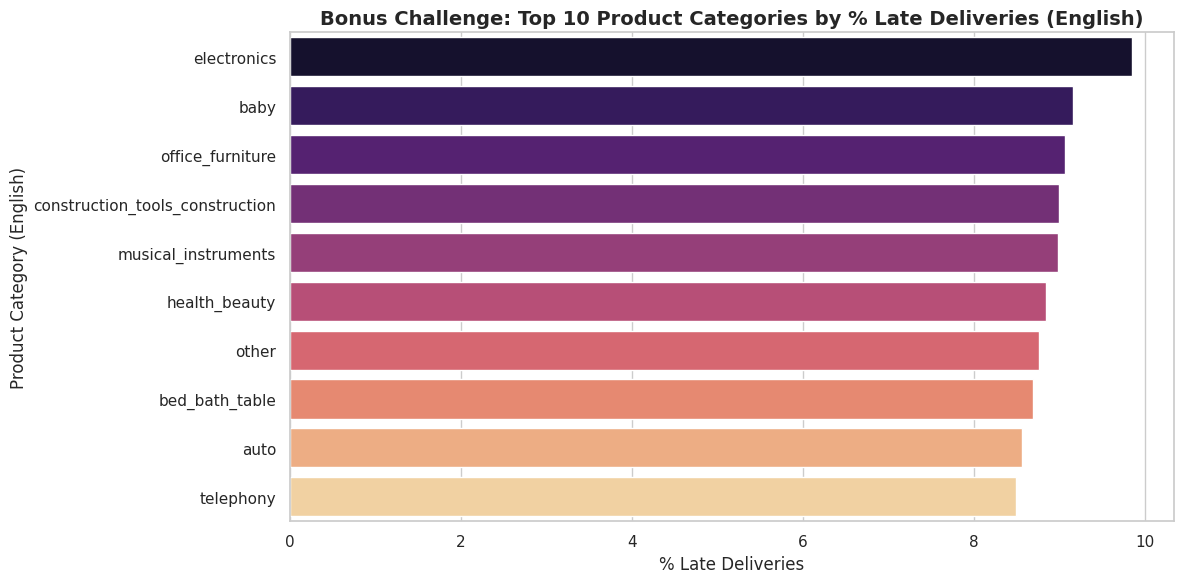

Bonus dataset exported successfully as 'category_delivery_audit.csv'!


In [26]:
# 4. Calculate % Late Orders per Category (Minimum 500 orders for statistical significance)
category_audit = bonus_df.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x != 'On Time').sum()),
    avg_review_score=('review_score', 'mean')
).reset_index()

category_audit['pct_late'] = (category_audit['late_orders'] / category_audit['total_orders']) * 100
significant_categories = category_audit[category_audit['total_orders'] >= 500].sort_values(by='pct_late', ascending=False)

print("--- TOP 10 PRODUCT CATEGORIES WITH HIGHEST % LATE DELIVERIES ---")
print(significant_categories.head(10))

# 5. Visualize Bonus Story
plt.figure(figsize=(12, 6))
sns.barplot(data=significant_categories.head(10), x='pct_late', y='product_category_name_english', palette='magma')
plt.title('Bonus Challenge: Top 10 Product Categories by % Late Deliveries (English)', fontsize=14, fontweight='bold')
plt.xlabel('% Late Deliveries')
plt.ylabel('Product Category (English)')
plt.tight_layout()
plt.show()

# 6. Export for Dashboard
significant_categories.to_csv('category_delivery_audit.csv', index=False)
print("Bonus dataset exported successfully as 'category_delivery_audit.csv'!")